In [39]:
# ==========================================================
# Parkinson's Disease Severity Prediction using XGBoost
# Oxford Parkinson's Telemonitoring Dataset
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import json
import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBRegressor

from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV,
    cross_val_score
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import shap

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [40]:
# ==========================================================
# Load Dataset
# ==========================================================

df = pd.read_csv("../datasets/parkinsons_real/parkinsons_telemonitoring_updrs.csv")

display(df.head())

,subject#,age,sex,test_time,motor_UPDRS,total_UPDRS,Jitter(%),Jitter(Abs),Jitter:RAP,Jitter:PPQ5,Jitter:DDP,Shimmer,Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,Shimmer:APQ11,Shimmer:DDA,NHR,HNR,RPDE,DFA,PPE
0,1,72,0,5.6431,28.199,34.398,0.00662,0.000034,0.00401,0.00317,0.01204,0.02565,0.230,0.01438,0.01309,0.01662,0.04314,0.014290,21.640,0.41888,0.54842,0.16006
1,1,72,0,12.6660,28.447,34.894,0.00300,0.000017,0.00132,0.00150,0.00395,0.02024,0.179,0.00994,0.01072,0.01689,0.02982,0.011112,27.183,0.43493,0.56477,0.10810
2,1,72,0,19.6810,28.695,35.389,0.00481,0.000025,0.00205,0.00208,0.00616,0.01675,0.181,0.00734,0.00844,0.01458,0.02202,0.020220,23.047,0.46222,0.54405,0.21014
3,1,72,0,25.6470,28.905,35.810,0.00528,0.000027,0.00191,0.00264,0.00573,0.02309,0.327,0.01106,0.01265,0.01963,0.03317,0.027837,24.445,0.48730,0.57794,0.33277
4,1,72,0,33.6420,29.187,36.375,0.00335,0.000020,0.00093,0.00130,0.00278,0.01703,0.176,0.00679,0.00929,0.01819,0.02036,0.011625,26.126,0.47188,0.56122,0.19361


In [41]:
# ==========================================================
# Dataset Information
# ==========================================================

print("="*60)
print("DATASET SHAPE")
print("="*60)

print(df.shape)

print()

print("="*60)
print("DATASET INFO")
print("="*60)

df.info()

print()

print("="*60)
print("STATISTICS")
print("="*60)

display(df.describe())

print()

print("="*60)
print("MISSING VALUES")
print("="*60)

display(df.isnull().sum())

DATASET SHAPE
(5875, 22)

DATASET INFO
<class 'pandas.DataFrame'>
RangeIndex: 5875 entries, 0 to 5874
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   subject#       5875 non-null   int64  
 1   age            5875 non-null   int64  
 2   sex            5875 non-null   int64  
 3   test_time      5875 non-null   float64
 4   motor_UPDRS    5875 non-null   float64
 5   total_UPDRS    5875 non-null   float64
 6   Jitter(%)      5875 non-null   float64
 7   Jitter(Abs)    5875 non-null   float64
 8   Jitter:RAP     5875 non-null   float64
 9   Jitter:PPQ5    5875 non-null   float64
 10  Jitter:DDP     5875 non-null   float64
 11  Shimmer        5875 non-null   float64
 12  Shimmer(dB)    5875 non-null   float64
 13  Shimmer:APQ3   5875 non-null   float64
 14  Shimmer:APQ5   5875 non-null   float64
 15  Shimmer:APQ11  5875 non-null   float64
 16  Shimmer:DDA    5875 non-null   float64
 17  NHR            5875 non-

,subject#,age,sex,test_time,motor_UPDRS,total_UPDRS,Jitter(%),Jitter(Abs),Jitter:RAP,Jitter:PPQ5,Jitter:DDP,Shimmer,Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,Shimmer:APQ11,Shimmer:DDA,NHR,HNR,RPDE,DFA,PPE
count,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000,5875.000000
mean,21.494128,64.804936,0.317787,92.863722,21.296229,29.018942,0.006154,0.000044,0.002987,0.003277,0.008962,0.034035,0.310960,0.017156,0.020144,0.027481,0.051467,0.032120,21.679495,0.541473,0.653240,0.219589
std,12.372279,8.821524,0.465656,53.445602,8.129282,10.700283,0.005624,0.000036,0.003124,0.003732,0.009371,0.025835,0.230254,0.013237,0.016664,0.019986,0.039711,0.059692,4.291096,0.100986,0.070902,0.091498
min,1.000000,36.000000,0.000000,-4.262500,5.037700,7.000000,0.000830,0.000002,0.000330,0.000430,0.000980,0.003060,0.026000,0.001610,0.001940,0.002490,0.004840,0.000286,1.659000,0.151020,0.514040,0.021983
25%,10.000000,58.000000,0.000000,46.847500,15.000000,21.371000,0.003580,0.000022,0.001580,0.001820,0.004730,0.019120,0.175000,0.009280,0.010790,0.015665,0.027830,0.010955,19.406000,0.469785,0.596180,0.156340
50%,22.000000,65.000000,0.000000,91.523000,20.871000,27.576000,0.004900,0.000035,0.002250,0.002490,0.006750,0.027510,0.253000,0.013700,0.015940,0.022710,0.041110,0.018448,21.920000,0.542250,0.643600,0.205500
75%,33.000000,72.000000,1.000000,138.445000,27.596500,36.399000,0.006800,0.000053,0.003290,0.003460,0.009870,0.039750,0.365000,0.020575,0.023755,0.032715,0.061735,0.031463,24.444000,0.614045,0.711335,0.264490
max,42.000000,85.000000,1.000000,215.490000,39.511000,54.992000,0.099990,0.000446,0.057540,0.069560,0.172630,0.268630,2.107000,0.162670,0.167020,0.275460,0.488020,0.748260,37.875000,0.966080,0.865600,0.731730



MISSING VALUES


subject#         0
age              0
sex              0
test_time        0
motor_UPDRS      0
total_UPDRS      0
Jitter(%)        0
Jitter(Abs)      0
Jitter:RAP       0
Jitter:PPQ5      0
Jitter:DDP       0
Shimmer          0
Shimmer(dB)      0
Shimmer:APQ3     0
Shimmer:APQ5     0
Shimmer:APQ11    0
Shimmer:DDA      0
NHR              0
HNR              0
RPDE             0
DFA              0
PPE              0
dtype: int64

In [42]:
print("="*60)
print("PATIENT INFORMATION")
print("="*60)

print("Unique Patients :",df["subject#"].nunique())

patient_recordings = df.groupby("subject#").size()

display(patient_recordings.describe())

PATIENT INFORMATION
Unique Patients : 42


count     42.000000
mean     139.880952
std       15.542550
min      101.000000
25%      130.000000
50%      141.000000
75%      149.750000
max      168.000000
dtype: float64

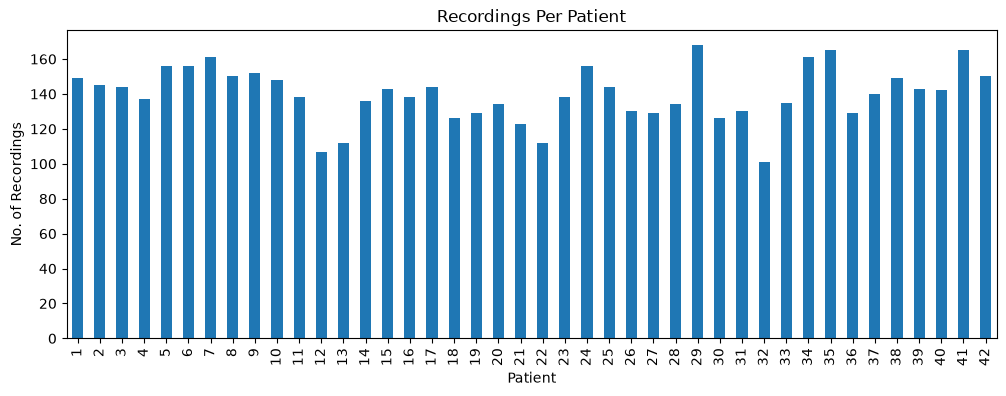

In [43]:
plt.figure(figsize=(12,4))

patient_recordings.plot(
    kind="bar"
)

plt.title("Recordings Per Patient")

plt.xlabel("Patient")

plt.ylabel("No. of Recordings")

plt.show()

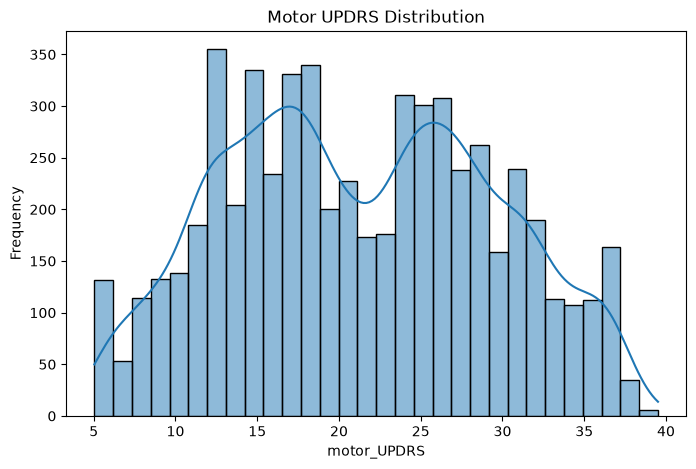

In [44]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["motor_UPDRS"],
    bins=30,
    kde=True
)

plt.title("Motor UPDRS Distribution")

plt.xlabel("motor_UPDRS")

plt.ylabel("Frequency")

plt.show()

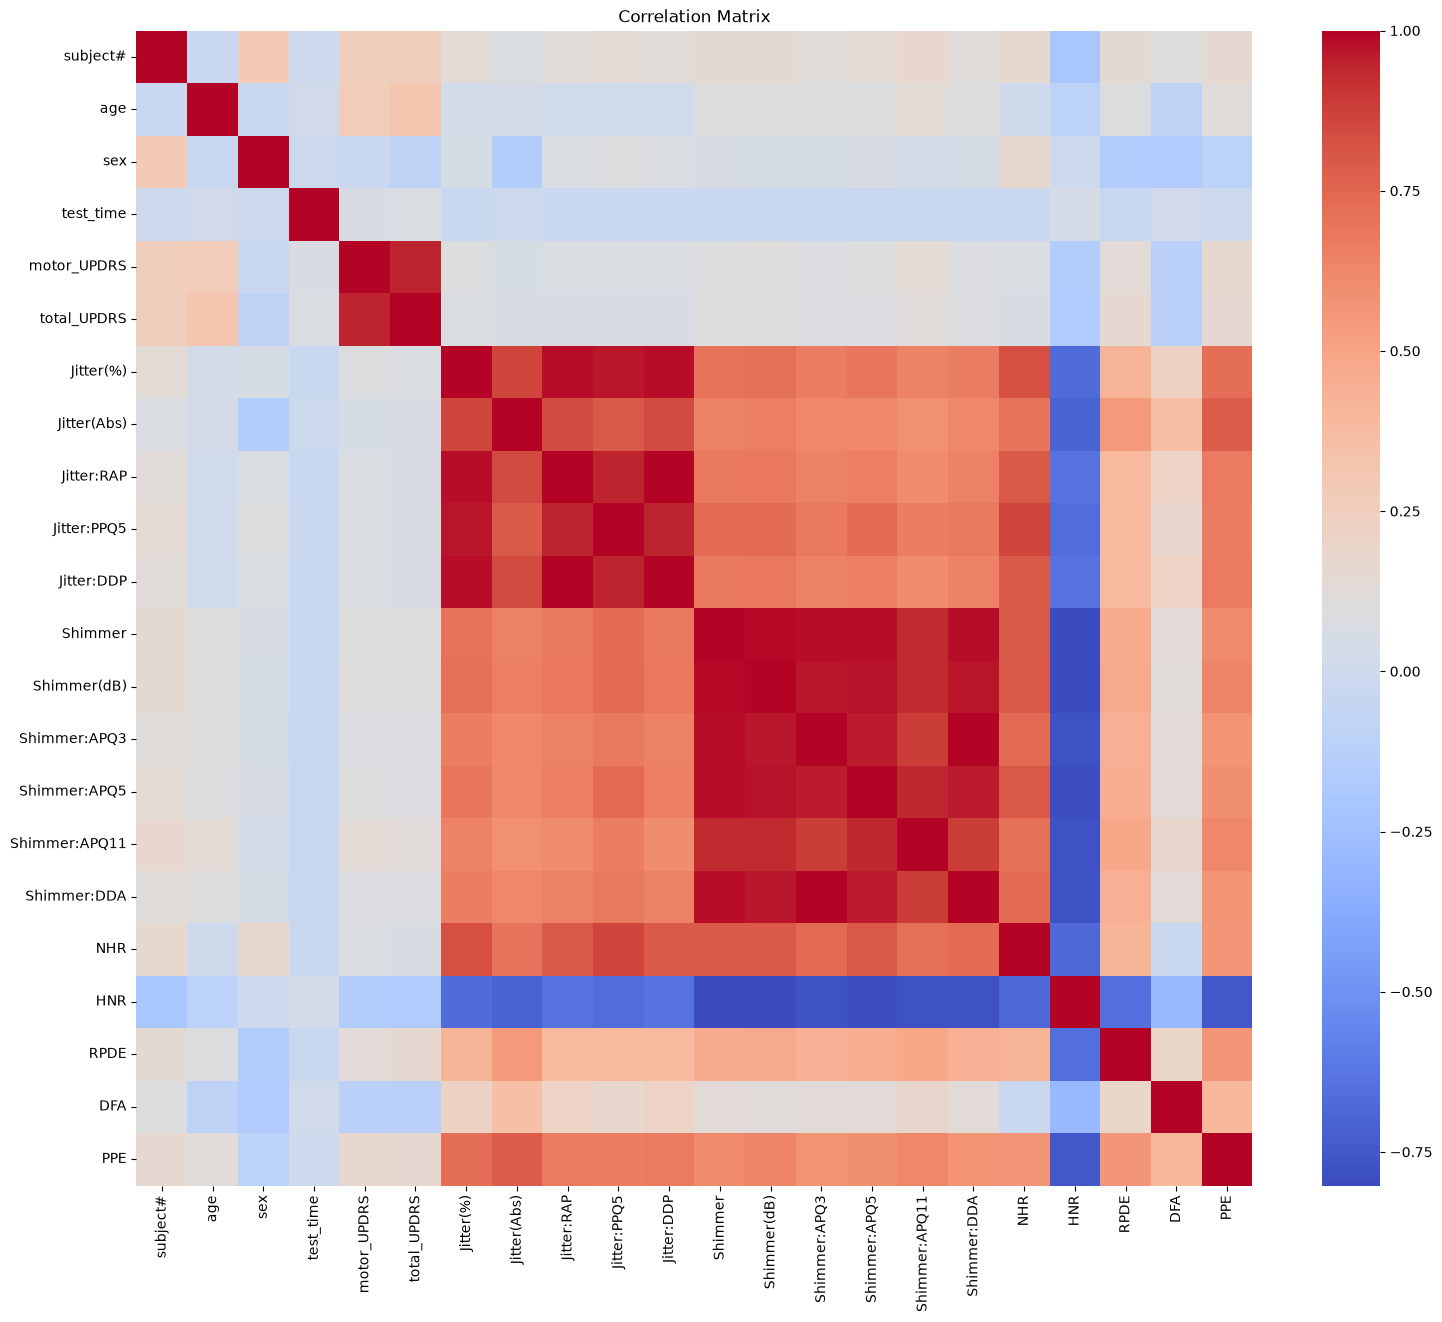

In [45]:
plt.figure(figsize=(18,15))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

In [46]:
corr = df.corr(numeric_only=True)["motor_UPDRS"]

display(
    corr.sort_values(ascending=False)
)

motor_UPDRS      1.000000
total_UPDRS      0.947231
age              0.273665
subject#         0.252919
PPE              0.162433
Shimmer:APQ11    0.136560
RPDE             0.128607
Shimmer(dB)      0.110076
Shimmer          0.102349
Shimmer:APQ5     0.092105
Jitter(%)        0.084816
Shimmer:APQ3     0.084261
Shimmer:DDA      0.084260
Jitter:PPQ5      0.076291
NHR              0.074967
Jitter:DDP       0.072698
Jitter:RAP       0.072684
test_time        0.067918
Jitter(Abs)      0.050903
sex             -0.031205
DFA             -0.116242
HNR             -0.157029
Name: motor_UPDRS, dtype: float64

In [47]:
target = "motor_UPDRS"

drop_columns = [
    "subject#",
    "motor_UPDRS",
    "total_UPDRS"
]

X = df.drop(columns=drop_columns)

y = df[target]

print("Features :",X.shape)

print("Target :",y.shape)

Features : (5875, 19)
Target : (5875,)


In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Train Shape :",X_train.shape)

print("Test Shape :",X_test.shape)

Train Shape : (4700, 19)
Test Shape : (1175, 19)


In [49]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Train Shape :",X_train.shape)

print("Test Shape :",X_test.shape)

Train Shape : (4700, 19)
Test Shape : (1175, 19)


In [50]:
# ==========================================================
# Hyperparameter Tuning
# ==========================================================

param_grid = {

    "n_estimators": [200,300,500,700,1000],

    "learning_rate": [0.01,0.03,0.05,0.1],

    "max_depth": [3,4,5,6,8],

    "min_child_weight": [1,3,5,7],

    "subsample": [0.6,0.7,0.8,0.9,1.0],

    "colsample_bytree": [0.6,0.7,0.8,0.9,1.0],

    "gamma": [0,0.1,0.2,0.3],

    "reg_alpha": [0,0.01,0.1,1],

    "reg_lambda": [0.5,1,2,5]

}

In [52]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 0.1, 0.2]
}

random_search = RandomizedSearchCV(

    estimator=XGBRegressor(
        objective="reg:squarederror",
        random_state=42
    ),

    param_distributions=param_grid,

    n_iter=10,

    scoring="r2",

    cv=3,

    random_state=42,

    n_jobs=-1,

    verbose=1

)

random_search.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=True,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraints...
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None, ...),
                   n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.8, 1.0],
                                        'gamma': [0, 0.1, 0.2],
                                        'learning_rate': [0.01, 0.03, 0.05,
                                                          0.1],
                                        'max_depth': [3, 4, 5, 6],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [200, 300, 500],
                                        'subsample': [0.8, 1.0]},
                   random_state=42, scoring='r2', verbose=1)

In [53]:
print("=" * 60)
print("BEST PARAMETERS")
print("=" * 60)

print(random_search.best_params_)

print()

print("Best Cross Validation Score")

print(random_search.best_score_)

BEST PARAMETERS
{'subsample': 0.8, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 6, 'learning_rate': 0.1, 'gamma': 0.2, 'colsample_bytree': 1.0}

Best Cross Validation Score
0.9508348694695248


In [54]:
best_model = random_search.best_estimator_

In [55]:
train_pred = best_model.predict(X_train)

test_pred = best_model.predict(X_test)

In [56]:
print("=" * 60)
print("TRAIN METRICS")
print("=" * 60)

train_mae = mean_absolute_error(
    y_train,
    train_pred
)

train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        train_pred
    )
)

train_r2 = r2_score(
    y_train,
    train_pred
)

print(f"MAE  : {train_mae:.4f}")
print(f"RMSE : {train_rmse:.4f}")
print(f"R²   : {train_r2:.4f}")

print()

print("=" * 60)
print("TEST METRICS")
print("=" * 60)

test_mae = mean_absolute_error(
    y_test,
    test_pred
)

test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        test_pred
    )
)

test_r2 = r2_score(
    y_test,
    test_pred
)

print(f"MAE  : {test_mae:.4f}")
print(f"RMSE : {test_rmse:.4f}")
print(f"R²   : {test_r2:.4f}")

TRAIN METRICS
MAE  : 0.3015
RMSE : 0.4358
R²   : 0.9971

TEST METRICS
MAE  : 0.9784
RMSE : 1.4911
R²   : 0.9652


In [59]:
print("="*60)
print("FINAL MODEL SUMMARY")
print("="*60)

print(f"Training Samples : {len(X_train)}")
print(f"Testing Samples  : {len(X_test)}")

print()

print(f"Train MAE : {train_mae:.4f}")
print(f"Train RMSE: {train_rmse:.4f}")
print(f"Train R²  : {train_r2:.4f}")

print()

print(f"Test MAE : {test_mae:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")
print(f"Test R²  : {test_r2:.4f}")

print()

FINAL MODEL SUMMARY
Training Samples : 4700
Testing Samples  : 1175

Train MAE : 0.3015
Train RMSE: 0.4358
Train R²  : 0.9971

Test MAE : 0.9784
Test RMSE: 1.4911
Test R²  : 0.9652



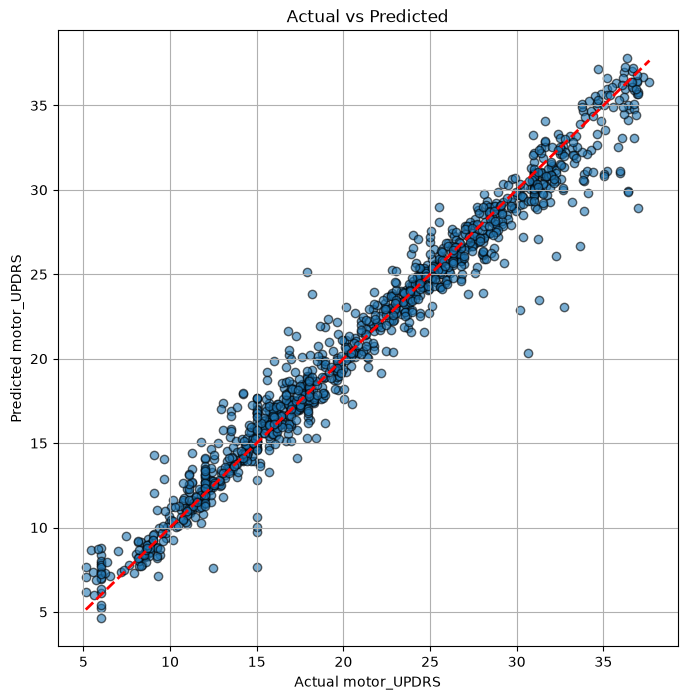

In [60]:
# ==========================================================
# Actual vs Predicted
# ==========================================================

plt.figure(figsize=(8,8))

plt.scatter(
    y_test,
    test_pred,
    alpha=0.6,
    edgecolors="black"
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--",
    linewidth=2
)

plt.xlabel("Actual motor_UPDRS")
plt.ylabel("Predicted motor_UPDRS")
plt.title("Actual vs Predicted")

plt.grid(True)

plt.show()

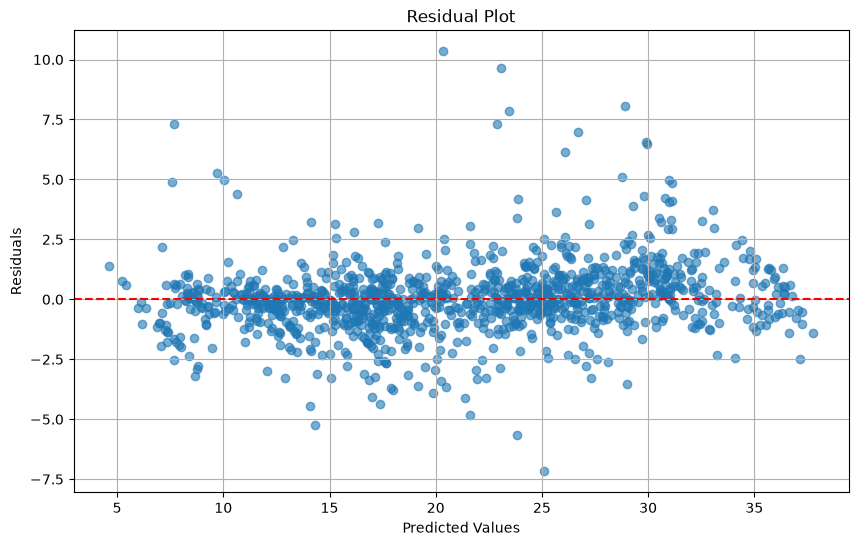

In [61]:
# ==========================================================
# Residual Analysis
# ==========================================================

residuals = y_test - test_pred

plt.figure(figsize=(10,6))

plt.scatter(
    test_pred,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.grid(True)

plt.show()

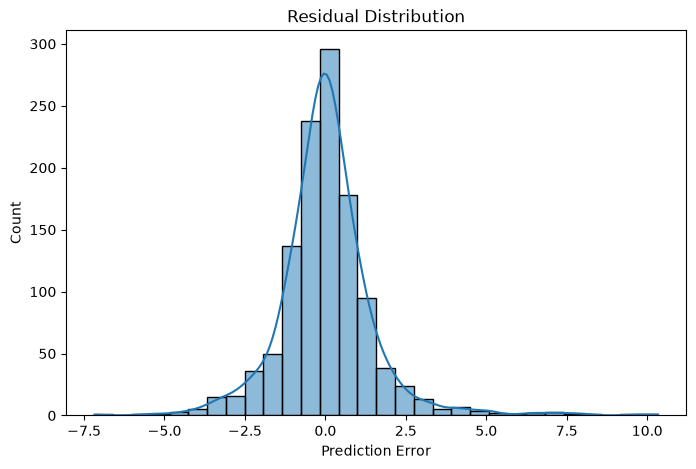

In [62]:
plt.figure(figsize=(8,5))

sns.histplot(
    residuals,
    bins=30,
    kde=True
)

plt.title("Residual Distribution")

plt.xlabel("Prediction Error")

plt.show()

In [63]:
importance = pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

display(importance)

age              0.367774
sex              0.271762
DFA              0.062821
Jitter(Abs)      0.035643
Shimmer:APQ5     0.032998
HNR              0.030940
Shimmer:DDA      0.029609
test_time        0.028011
Shimmer:APQ3     0.018812
Shimmer          0.016682
PPE              0.015364
NHR              0.015034
Shimmer(dB)      0.013645
Jitter:DDP       0.013388
Shimmer:APQ11    0.013028
RPDE             0.012371
Jitter:RAP       0.008685
Jitter:PPQ5      0.007515
Jitter(%)        0.005919
dtype: float32

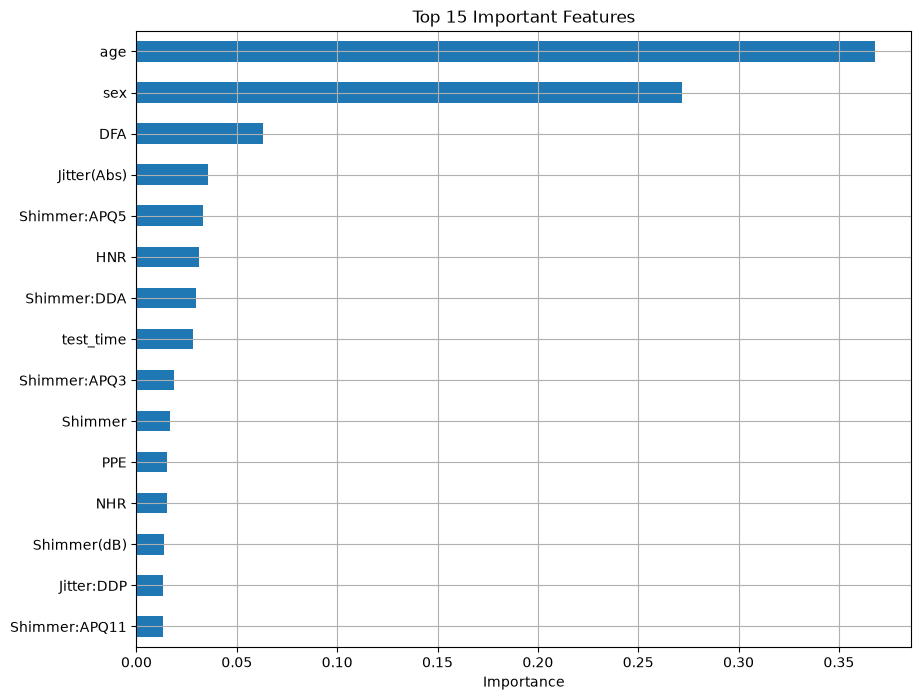

In [64]:
plt.figure(figsize=(10,8))

importance.head(15).plot(
    kind="barh"
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")

plt.title("Top 15 Important Features")

plt.grid(True)

plt.show()

In [66]:
import shap

shap.initjs()

explainer = shap.TreeExplainer(best_model)

shap_values = explainer.shap_values(X_test)

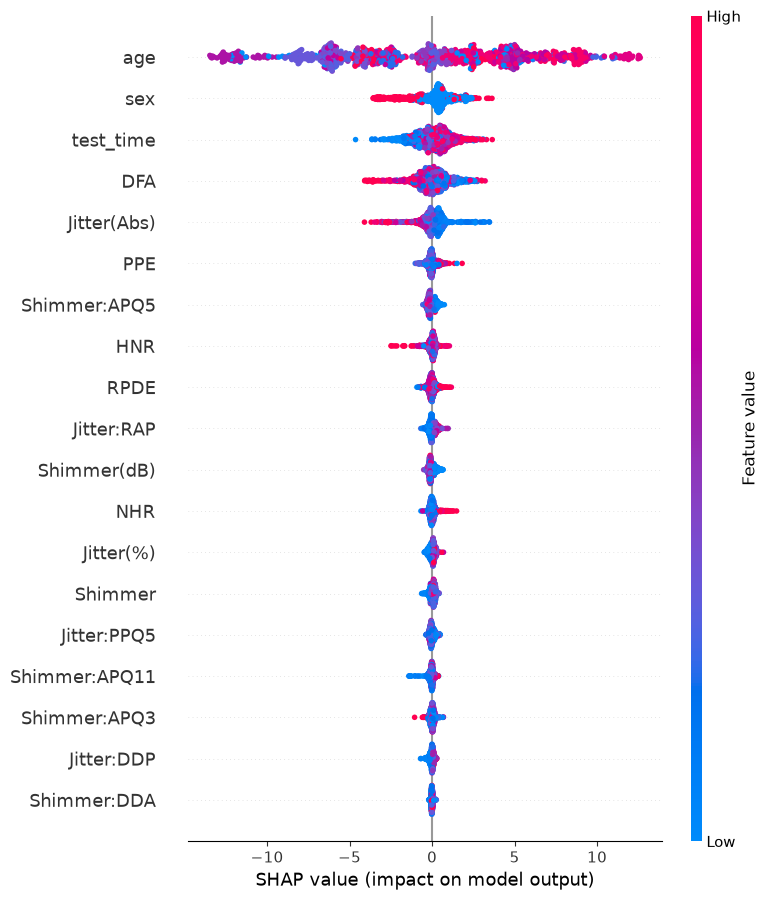

In [67]:
shap.summary_plot(
    shap_values,
    X_test
)

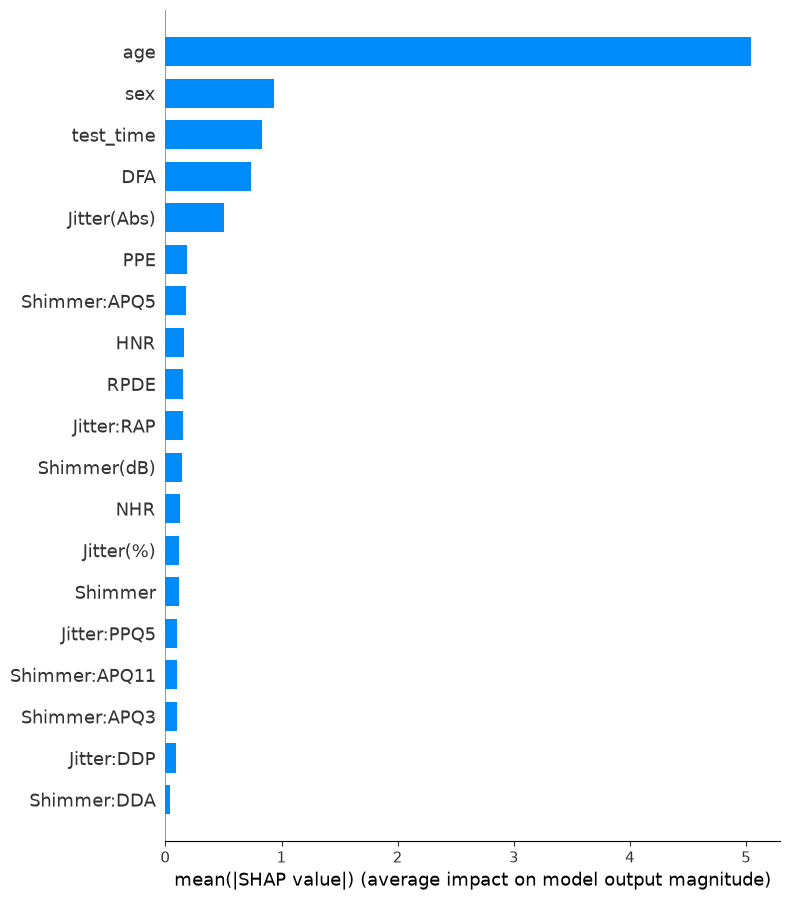

In [68]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

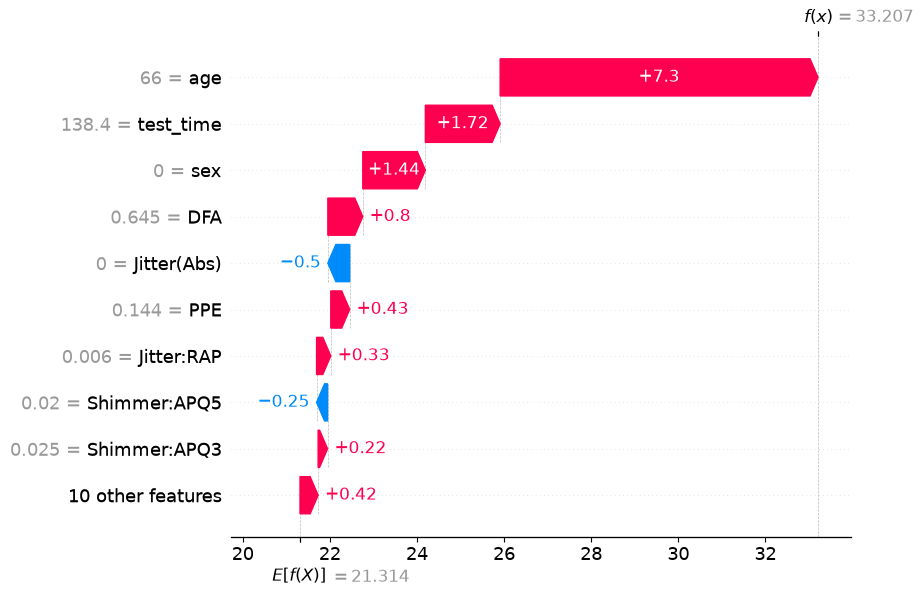

In [69]:
sample_index = 0

shap.plots.waterfall(

    shap.Explanation(

        values=shap_values[sample_index],

        base_values=explainer.expected_value,

        data=X_test.iloc[sample_index],

        feature_names=X.columns

    )

)

In [70]:
joblib.dump(
    best_model,
    "../models/parkinsons_xgb.joblib"
)

joblib.dump(
    list(X.columns),
    "../models/parkinsons_updrs_features.joblib"
)

print("Model Saved Successfully!")
print("Feature columns saved to parkinsons_updrs_features.joblib")

Model Saved Successfully!


In [71]:
metrics = {

    "Train_MAE": float(train_mae),
    "Train_RMSE": float(train_rmse),
    "Train_R2": float(train_r2),

    "Test_MAE": float(test_mae),
    "Test_RMSE": float(test_rmse),
    "Test_R2": float(test_r2),

    "Best_Parameters": random_search.best_params_

}

with open("../models/parkinsons_metrics.json","w") as f:

    json.dump(metrics,f,indent=4)

print("Metrics Saved Successfully!")

Metrics Saved Successfully!


In [72]:
loaded_model = joblib.load(
    "../models/parkinsons_xgb.joblib"
)

prediction = loaded_model.predict(
    X_test.iloc[[0]]
)

print("Prediction :",prediction[0])
print("Actual     :",y_test.iloc[0])


Prediction : 33.207314
Actual     : 33.084


# Conclusion

Successfully trained an XGBoost Regressor to predict Parkinson's motor_UPDRS severity from biomedical voice biomarkers.

Pipeline Completed:

- Data Exploration
- Data Preparation
- Train/Test Split
- Hyperparameter Tuning
- Model Evaluation
- Feature Importance Analysis
- SHAP Explainability
- Model Serialization (.joblib)
- Metrics Export (.json)

The saved model will be integrated into the FastAPI backend for real-time inference.